Restarted olympics (Python 3.11.15)

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'sph'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
time_dim = noise['time'].values.astype('float64')

noise_masked = ds.isel(south_north=0, east_west=0)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)

NameError: name 'noise' is not defined

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'sph'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(ds, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)

NameError: name 'noise' is not defined

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'sph'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
# time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(ds, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)

ValueError: x and y must be the same size

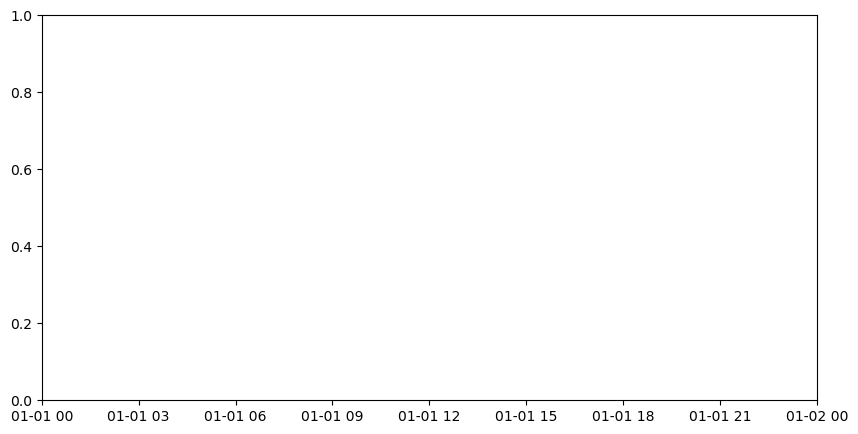

In [ ]:
def harmonic_formula(order):
    """
    Harmonic function custom to given order (based on number of coefficents passed in *coeffs). 
    This function outputs a formula to pass to statsmodels formula API. 
    """
    # *coeffs: captures any number of coefficients (a1, b1, a2, b2, a3, b3...)
    # omega: fundamental frequency of the entire dataset window (a year worth of daily data)
    omega = '(2 * np.pi * d)/365'
    # TODO: 
    # TODO: error if t isnt measured in days because then theres a mismatch with omega

    res = 'y_var ~ '
    for i in range(1, order + 1):
        res += f'np.cos({i} * {omega}) + np.sin({i} * {omega})'
        
        # Add a plus sign between terms for each order
        if i != order:
            res += ' + '

    return res
    # TODO: check what time values are set to in the dataset (should be numerical offset relative to start date of the dataset)

def fit_harmonic(y, d, order):
    # Pack the 1D arrays into a dictionary for patsy/formula API
    data_dict = {'y_var': y, 'd': d}
    
    # Define your formula (you can swap this with your dynamic harmonic_n function)
    formula = harmonic_formula(order = order)
    
    # Fit model using the formula API
    model = smf.ols(formula = formula, data = data_dict).fit()
    
    # model.params returns a pandas Series (Intercept, cos, sin)
    return model.params.values

order = 2
expected_num_coeffs = (2 * order) + 1
ds['day_of_year'] = ds['time'].dt.dayofyear

# Use xarray's apply_ufunc identically to before
coeffs = xr.apply_ufunc(
    fit_harmonic, 
    ds[var], ds['day_of_year'], 
    kwargs = {'order': order},
    input_core_dims = [['time'], ['time']],
    output_core_dims = [['coeff']],
    vectorize = True,
    dask = 'parallelized',
    output_dtypes = [float],
    dask_gufunc_kwargs = {'output_sizes': {'coeff': expected_num_coeffs}}
)

# Rename coeffs dimensions to match your model's grid layout if needed
coeffs = coeffs.rename({'lat': 'south_north', 'lon': 'east_west'})

# Now assign the 2D coordinates safely
coeffs = coeffs.assign_coords({
    'lat': ds['lat'],
    'lon': ds['lon']
})


# 1. Select a specific grid cell (e.g., first lat/lon or a specific location)
# If your dataset has spatial dims, pick one: cell_coeffs = coeffs.isel(lat=0, lon=0)
# Or if it's a single time-series:
cell_coeffs = loc_mask(coeffs, 'other', lat_min, lat_max, lon_min, lon_max)
cell_data = noise_masked.isel(south_north=0, east_west=0).squeeze()

# 2. Extract the intercept (index 0) as a clean float scalar using xarray selection
intercept = cell_coeffs.isel(coeff=0).values.item()

# 3. Reconstruct the fitted values over a 365-day range
d_plot = np.linspace(1, 365, 365)
y_pred = np.full_like(d_plot, intercept)

omega = (2 * np.pi) / 365

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data[var].values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
cell_data[var].values

array([[[ 5.01376345e-04,  3.99650320e-04,  2.80509351e-04, ...,
          3.62927909e-04,  3.62120158e-04,  3.05233389e-04],
        [ 5.40199968e-04,  4.64531201e-04,  2.95109542e-04, ...,
          3.95381787e-04,  3.84777992e-04,  2.91280390e-04],
        [ 5.39126480e-04,  4.94417546e-04,  2.84530261e-04, ...,
          4.14557772e-04,  4.23181063e-04,  2.88209542e-04],
        ...,
        [-5.28553062e-05, -6.28040382e-05, -4.33282141e-05, ...,
          3.05269246e-04,  3.33226618e-04,  2.83427262e-04],
        [-1.54182416e-05, -1.30810030e-05, -5.20769257e-06, ...,
          3.08626222e-04,  2.70892355e-04,  2.06658743e-04],
        [ 1.85119016e-05,  3.34748991e-05,  3.59875540e-05, ...,
          3.27307608e-04,  2.55792765e-04,  1.49266954e-04]],

       [[ 3.60159411e-04,  2.60189875e-04,  1.42430667e-04, ...,
          2.43940860e-04,  2.55808210e-04,  2.12385444e-04],
        [ 4.04770850e-04,  3.38165663e-04,  1.60938516e-04, ...,
          2.86395917e-04,  2.91515896e

In [ ]:
noise_masked[var]

<xarray.DataArray 'sph' (time: 365, lat: 111, lon: 90, south_north: 1,
                         east_west: 1)> Size: 29MB
array([[[[[ 5.01376345e-04]],

         [[ 3.99650320e-04]],

         [[ 2.80509351e-04]],

         ...,

         [[ 3.62927909e-04]],

         [[ 3.62120158e-04]],

         [[ 3.05233389e-04]]],


        [[[ 5.40199968e-04]],

         [[ 4.64531201e-04]],

         [[ 2.95109542e-04]],
...
         [[ 3.16815809e-04]],

         [[ 2.28760479e-04]],

         [[ 1.69179009e-04]]],


        [[[ 7.73332580e-05]],

         [[ 8.72656366e-05]],

         [[ 6.69475390e-05]],

         ...,

         [[ 3.44314523e-04]],

         [[ 2.13879044e-04]],

         [[ 1.48132253e-04]]]]], shape=(365, 111, 90, 1, 1))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      (south_north, east_west) float32 4B 40.12
    lon      (south_north, east_west) float32 4B -110.1
Dimensions without coordinates: south_north, east_west

In [ ]:
noise_masked[var].lat

<xarray.DataArray 'lat' (south_north: 1, east_west: 1)> Size: 4B
array([[40.120266]], dtype=float32)
Coordinates:
    lon      (south_north, east_west) float32 4B -110.1
    lat      (south_north, east_west) float32 4B 40.12
Dimensions without coordinates: south_north, east_west

In [ ]:
noise_masked[var]['lat']

<xarray.DataArray 'lat' (south_north: 1, east_west: 1)> Size: 4B
array([[40.120266]], dtype=float32)
Coordinates:
    lon      (south_north, east_west) float32 4B -110.1
    lat      (south_north, east_west) float32 4B 40.12
Dimensions without coordinates: south_north, east_west

In [ ]:
ds['lat'].shape

(111, 90)

In [ ]:
ds['lat'].values

array([[39.217117, 39.21799 , 39.21884 , ..., 39.22127 , 39.220478,
        39.21966 ],
       [39.25305 , 39.253933, 39.25478 , ..., 39.257225, 39.256424,
        39.255615],
       [39.289013, 39.289886, 39.290737, ..., 39.29318 , 39.29238 ,
        39.29157 ],
       ...,
       [43.1008  , 43.10172 , 43.102623, ..., 43.1052  , 43.10437 ,
        43.1035  ],
       [43.13674 , 43.13766 , 43.13857 , ..., 43.14116 , 43.140312,
        43.139442],
       [43.172684, 43.173603, 43.174515, ..., 43.177097, 43.176247,
        43.17539 ]], shape=(111, 90), dtype=float32)

In [ ]:
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 365, 'lat': 111, 'lon': 90, 'south_north': 111, 'east_west': 90})

In [ ]:
ds.coords

Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      (south_north, east_west) float32 40kB 39.22 39.22 ... 43.18 43.18
    lon      (south_north, east_west) float32 40kB -114.1 -114.1 ... -109.9

In [ ]:
cell_data.shape

AttributeError: 'Dataset' object has no attribute 'shape'

In [ ]:
cell_data[var].shape

(365, 111, 90)

In [ ]:
def harmonic_formula(order):
    """
    Harmonic function custom to given order (based on number of coefficents passed in *coeffs). 
    This function outputs a formula to pass to statsmodels formula API. 
    """
    # *coeffs: captures any number of coefficients (a1, b1, a2, b2, a3, b3...)
    # omega: fundamental frequency of the entire dataset window (a year worth of daily data)
    omega = '(2 * np.pi * d)/365'
    # TODO: 
    # TODO: error if t isnt measured in days because then theres a mismatch with omega

    res = 'y_var ~ '
    for i in range(1, order + 1):
        res += f'np.cos({i} * {omega}) + np.sin({i} * {omega})'
        
        # Add a plus sign between terms for each order
        if i != order:
            res += ' + '

    return res
    # TODO: check what time values are set to in the dataset (should be numerical offset relative to start date of the dataset)

def fit_harmonic(y, d, order):
    # Pack the 1D arrays into a dictionary for patsy/formula API
    data_dict = {'y_var': y, 'd': d}
    
    # Define your formula (you can swap this with your dynamic harmonic_n function)
    formula = harmonic_formula(order = order)
    
    # Fit model using the formula API
    model = smf.ols(formula = formula, data = data_dict).fit()
    
    # model.params returns a pandas Series (Intercept, cos, sin)
    return model.params.values

order = 2
expected_num_coeffs = (2 * order) + 1
ds['day_of_year'] = ds['time'].dt.dayofyear

# Use xarray's apply_ufunc identically to before
coeffs = xr.apply_ufunc(
    fit_harmonic, 
    ds[var], ds['day_of_year'], 
    kwargs = {'order': order},
    input_core_dims = [['time'], ['time']],
    output_core_dims = [['coeff']],
    vectorize = True,
    dask = 'parallelized',
    output_dtypes = [float],
    dask_gufunc_kwargs = {'output_sizes': {'coeff': expected_num_coeffs}}
)

# Rename coeffs dimensions to match your model's grid layout if needed
coeffs = coeffs.rename({'lat': 'south_north', 'lon': 'east_west'})

# Now assign the 2D coordinates safely
coeffs = coeffs.assign_coords({
    'lat': ds['lat'],
    'lon': ds['lon']
})


# 1. Select a specific grid cell (e.g., first lat/lon or a specific location)
# If your dataset has spatial dims, pick one: cell_coeffs = coeffs.isel(lat=0, lon=0)
# Or if it's a single time-series:
cell_coeffs = loc_mask(coeffs, 'other', lat_min, lat_max, lon_min, lon_max)
cell_data = noise_masked.isel(south_north=0, east_west=0).squeeze()
cell_data = cell_data[var].squeeze()  # Ensure it's 1D for plotting

# 2. Extract the intercept (index 0) as a clean float scalar using xarray selection
intercept = cell_coeffs.isel(coeff=0).values.item()

# 3. Reconstruct the fitted values over a 365-day range
d_plot = np.linspace(1, 365, 365)
y_pred = np.full_like(d_plot, intercept)

omega = (2 * np.pi) / 365

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data[var].values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

KeyError: 'sph'

<Figure size 1000x500 with 0 Axes>

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'uas'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
# time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(ds, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)

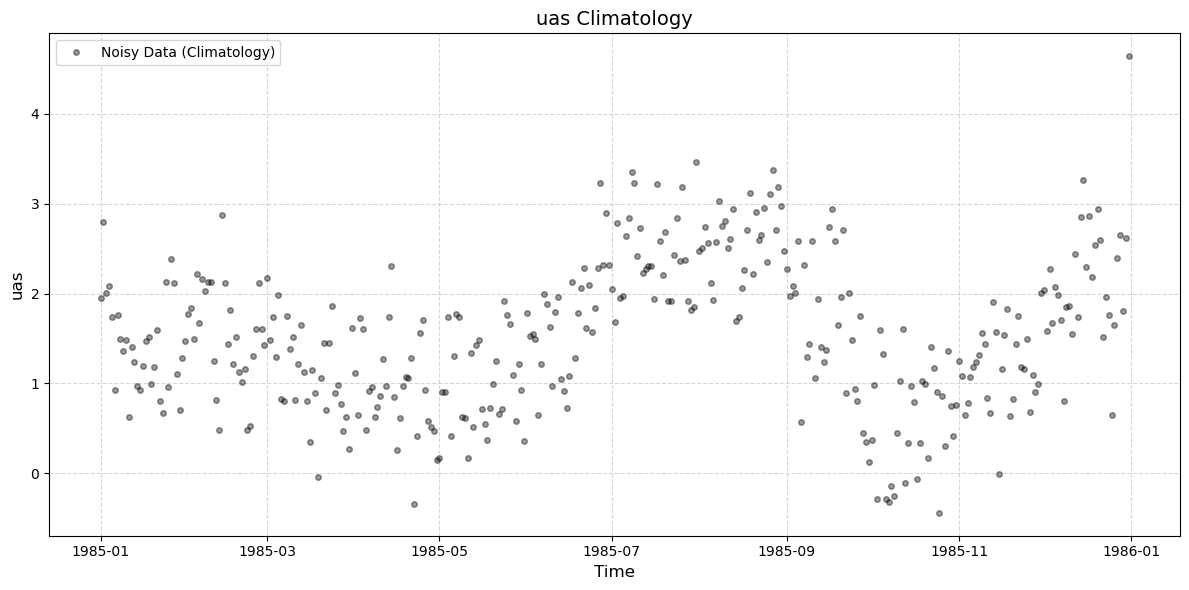

In [ ]:
# def order_call(ds, order, var):
#     """
#     Unpacks necessary coefficients from curvefit dataset.
#     """
#     # Access offset coeff (in every dataset)
#     a0 = ds[f'{var}_curvefit_coefficients'].sel(param = 'a0').values.item()
    
#     # Create list to store coeffs in
#     coeff = [a0]

#     # Loop through however many coeff are in that order of harmonic function
#     for i in range(1, order+1):
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'a{i}').values.item())
#         coeff.append(ds[f'{var}_curvefit_coefficients'].sel(param = f'b{i}').values.item())

#     return coeff

# first_coeff = order_call(first_masked, 1, var)
# second_coeff = order_call(second_masked, 2, var)
# third_coeff = order_call(third_masked, 3, var)

# # Pass them into your harmonic function to generate the smooth curve
# # * tells it to unpack the list
# smooth_first = harmonic_n(time_dim, *first_coeff) 
# smooth_second = harmonic_n(time_dim, *second_coeff)
# smooth_third = harmonic_n(time_dim, *third_coeff)

# # Squeeze out any extra dimensions (like lat, lon, or singleton axes) so it becomes a 1D array of length 60
# smooth_first_1d = np.squeeze(smooth_first)
# smooth_second_1d = np.squeeze(smooth_second)
# smooth_third_1d = np.squeeze(smooth_third)

# Also ensure your noise variable is 1D for that specific masked point
noise_y = noise_masked[var].isel(lat=0, lon=0).squeeze()


# ===============================
# - Plotting Harmonic Curves - 
# ===============================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    noise_masked['time'], 
    noise_y, 
    'ko', 
    alpha=0.4, 
    markersize=4, 
    label='Noisy Data (Climatology)'
)

# ax.plot(
#     noise_masked['time'], 
#     smooth_first_1d, 
#     'r-', 
#     linewidth=2, 
#     label='1st Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_second_1d, 
#     'g-', 
#     linewidth=2, 
#     label='2nd Order Harmonic'
# )

# ax.plot(
#     noise_masked['time'], 
#     smooth_third_1d, 
#     'b-', 
#     linewidth=2, 
#     label='3rd Order Harmonic'
# )

ax.set_title(f'{var} Climatology', fontsize = 14)
ax.set_xlabel('Time', fontsize = 12)
ax.set_ylabel(var, fontsize = 12)
ax.grid(True, linestyle = '--', alpha = 0.5)
ax.legend(frameon = True)

plt.tight_layout()
plt.show()

Connected to olympics (Python 3.11.15)

In [ ]:
def harmonic_formula(order):
    """
    Harmonic function custom to given order (based on number of coefficents passed in *coeffs). 
    This function outputs a formula to pass to statsmodels formula API. 
    """
    # *coeffs: captures any number of coefficients (a1, b1, a2, b2, a3, b3...)
    # omega: fundamental frequency of the entire dataset window (a year worth of daily data)
    omega = '(2 * np.pi * d)/365'
    # TODO: 
    # TODO: error if t isnt measured in days because then theres a mismatch with omega

    res = 'y_var ~ '
    for i in range(1, order + 1):
        res += f'np.cos({i} * {omega}) + np.sin({i} * {omega})'
        
        # Add a plus sign between terms for each order
        if i != order:
            res += ' + '

    return res
    # TODO: check what time values are set to in the dataset (should be numerical offset relative to start date of the dataset)

def fit_harmonic(y, d, order):
    # Pack the 1D arrays into a dictionary for patsy/formula API
    data_dict = {'y_var': y, 'd': d}
    
    # Define your formula (you can swap this with your dynamic harmonic_n function)
    formula = harmonic_formula(order = order)
    
    # Fit model using the formula API
    model = smf.ols(formula = formula, data = data_dict).fit()
    
    # model.params returns a pandas Series (Intercept, cos, sin)
    return model.params.values

order = 2
expected_num_coeffs = (2 * order) + 1
ds['day_of_year'] = ds['time'].dt.dayofyear

# Use xarray's apply_ufunc identically to before
coeffs = xr.apply_ufunc(
    fit_harmonic, 
    ds[var], ds['day_of_year'], 
    kwargs = {'order': order},
    input_core_dims = [['time'], ['time']],
    output_core_dims = [['coeff']],
    vectorize = True,
    dask = 'parallelized',
    output_dtypes = [float],
    dask_gufunc_kwargs = {'output_sizes': {'coeff': expected_num_coeffs}}
)

# Rename coeffs dimensions to match your model's grid layout if needed
coeffs = coeffs.rename({'lat': 'south_north', 'lon': 'east_west'})

# Now assign the 2D coordinates safely
coeffs = coeffs.assign_coords({
    'lat': ds['lat'],
    'lon': ds['lon']
})


# 1. Select a specific grid cell (e.g., first lat/lon or a specific location)
# If your dataset has spatial dims, pick one: cell_coeffs = coeffs.isel(lat=0, lon=0)
# Or if it's a single time-series:
cell_coeffs = loc_mask(coeffs, 'other', lat_min, lat_max, lon_min, lon_max)
cell_data = noise_masked.isel(south_north=0, east_west=0).squeeze()
cell_data = cell_data[var].squeeze()  # Ensure it's 1D for plotting

# 2. Extract the intercept (index 0) as a clean float scalar using xarray selection
intercept = cell_coeffs.isel(coeff=0).values.item()

# 3. Reconstruct the fitted values over a 365-day range
d_plot = np.linspace(1, 365, 365)
y_pred = np.full_like(d_plot, intercept)

omega = (2 * np.pi) / 365

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data[var].values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

NameError: name 'ds' is not defined

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'uas'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
# time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(ds, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)


def harmonic_formula(order):
    """
    Harmonic function custom to given order (based on number of coefficents passed in *coeffs). 
    This function outputs a formula to pass to statsmodels formula API. 
    """
    # *coeffs: captures any number of coefficients (a1, b1, a2, b2, a3, b3...)
    # omega: fundamental frequency of the entire dataset window (a year worth of daily data)
    omega = '(2 * np.pi * d)/365'
    # TODO: 
    # TODO: error if t isnt measured in days because then theres a mismatch with omega

    res = 'y_var ~ '
    for i in range(1, order + 1):
        res += f'np.cos({i} * {omega}) + np.sin({i} * {omega})'
        
        # Add a plus sign between terms for each order
        if i != order:
            res += ' + '

    return res
    # TODO: check what time values are set to in the dataset (should be numerical offset relative to start date of the dataset)

def fit_harmonic(y, d, order):
    # Pack the 1D arrays into a dictionary for patsy/formula API
    data_dict = {'y_var': y, 'd': d}
    
    # Define your formula (you can swap this with your dynamic harmonic_n function)
    formula = harmonic_formula(order = order)
    
    # Fit model using the formula API
    model = smf.ols(formula = formula, data = data_dict).fit()
    
    # model.params returns a pandas Series (Intercept, cos, sin)
    return model.params.values

order = 2
expected_num_coeffs = (2 * order) + 1
ds['day_of_year'] = ds['time'].dt.dayofyear

# Use xarray's apply_ufunc identically to before
coeffs = xr.apply_ufunc(
    fit_harmonic, 
    ds[var], ds['day_of_year'], 
    kwargs = {'order': order},
    input_core_dims = [['time'], ['time']],
    output_core_dims = [['coeff']],
    vectorize = True,
    dask = 'parallelized',
    output_dtypes = [float],
    dask_gufunc_kwargs = {'output_sizes': {'coeff': expected_num_coeffs}}
)

# Rename coeffs dimensions to match your model's grid layout if needed
coeffs = coeffs.rename({'lat': 'south_north', 'lon': 'east_west'})

# Now assign the 2D coordinates safely
coeffs = coeffs.assign_coords({
    'lat': ds['lat'],
    'lon': ds['lon']
})


# 1. Select a specific grid cell (e.g., first lat/lon or a specific location)
# If your dataset has spatial dims, pick one: cell_coeffs = coeffs.isel(lat=0, lon=0)
# Or if it's a single time-series:
cell_coeffs = loc_mask(coeffs, 'other', lat_min, lat_max, lon_min, lon_max)
cell_data = noise_masked.isel(south_north=0, east_west=0).squeeze()
cell_data = cell_data[var].squeeze()  # Ensure it's 1D for plotting

# 2. Extract the intercept (index 0) as a clean float scalar using xarray selection
intercept = cell_coeffs.isel(coeff=0).values.item()

# 3. Reconstruct the fitted values over a 365-day range
d_plot = np.linspace(1, 365, 365)
y_pred = np.full_like(d_plot, intercept)

omega = (2 * np.pi) / 365

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data[var].values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

KeyError: 'uas'

<Figure size 1000x500 with 0 Axes>

In [ ]:
"""
Author: Sydney Smith
Date Created: July 28, 2026
"""

import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import sys
import xarray as xr

# ==================================
# - Establish Relative File Path - 
# ==================================

current_dir = Path(__file__).resolve().parent
parent_dir = current_dir.parent
sys.path.append(str(parent_dir))

from austin import harmonic_n, loc_mask

# Define variable of interest
var = 'tmmn'

# Load entire year worth of climatological daily bias data (raw noisy datapoints)
climate_dir = parent_dir / 'climate_avg' / var
climate_files = sorted(glob.glob(f'{str(climate_dir)}/climate_avg_{var}*.nc'))
ds = xr.open_mfdataset(climate_files, combine = 'nested', concat_dim = 'time').load() # Load noise into RAM and strip from other files to save space

# # Load results from harmonic function calculations
# dir = '/uufs/chpc.utah.edu/common/home/strong-group7/sydney/olympics/WRF/debias/harmonics/'
# first = xr.open_dataset(f'{dir}harmonic1_{var}.nc')
# second = xr.open_dataset(f'{dir}harmonic2_{var}.nc')
# third = xr.open_dataset(f'{dir}harmonic3_{var}.nc')

# Set exmaple lat and lon values
lat_min, lat_max = 40.12, 40.13
lon_min, lon_max = -110.09, -110.04
# time_dim = noise['time'].values.astype('float64')

noise_masked = loc_mask(ds, 'other', lat_min, lat_max, lon_min, lon_max)
# first_masked = loc_mask(first, 'other', lat_min, lat_max, lon_min, lon_max)
# second_masked = loc_mask(second, 'other', lat_min, lat_max, lon_min, lon_max)
# third_masked = loc_mask(third, 'other', lat_min, lat_max, lon_min, lon_max)


def harmonic_formula(order):
    """
    Harmonic function custom to given order (based on number of coefficents passed in *coeffs). 
    This function outputs a formula to pass to statsmodels formula API. 
    """
    # *coeffs: captures any number of coefficients (a1, b1, a2, b2, a3, b3...)
    # omega: fundamental frequency of the entire dataset window (a year worth of daily data)
    omega = '(2 * np.pi * d)/365'
    # TODO: 
    # TODO: error if t isnt measured in days because then theres a mismatch with omega

    res = 'y_var ~ '
    for i in range(1, order + 1):
        res += f'np.cos({i} * {omega}) + np.sin({i} * {omega})'
        
        # Add a plus sign between terms for each order
        if i != order:
            res += ' + '

    return res
    # TODO: check what time values are set to in the dataset (should be numerical offset relative to start date of the dataset)

def fit_harmonic(y, d, order):
    # Pack the 1D arrays into a dictionary for patsy/formula API
    data_dict = {'y_var': y, 'd': d}
    
    # Define your formula (you can swap this with your dynamic harmonic_n function)
    formula = harmonic_formula(order = order)
    
    # Fit model using the formula API
    model = smf.ols(formula = formula, data = data_dict).fit()
    
    # model.params returns a pandas Series (Intercept, cos, sin)
    return model.params.values

order = 2
expected_num_coeffs = (2 * order) + 1
ds['day_of_year'] = ds['time'].dt.dayofyear

# Use xarray's apply_ufunc identically to before
coeffs = xr.apply_ufunc(
    fit_harmonic, 
    ds[var], ds['day_of_year'], 
    kwargs = {'order': order},
    input_core_dims = [['time'], ['time']],
    output_core_dims = [['coeff']],
    vectorize = True,
    dask = 'parallelized',
    output_dtypes = [float],
    dask_gufunc_kwargs = {'output_sizes': {'coeff': expected_num_coeffs}}
)

# Rename coeffs dimensions to match your model's grid layout if needed
coeffs = coeffs.rename({'lat': 'south_north', 'lon': 'east_west'})

# Now assign the 2D coordinates safely
coeffs = coeffs.assign_coords({
    'lat': ds['lat'],
    'lon': ds['lon']
})


# 1. Select a specific grid cell (e.g., first lat/lon or a specific location)
# If your dataset has spatial dims, pick one: cell_coeffs = coeffs.isel(lat=0, lon=0)
# Or if it's a single time-series:
cell_coeffs = loc_mask(coeffs, 'other', lat_min, lat_max, lon_min, lon_max)
cell_data = noise_masked.isel(south_north=0, east_west=0).squeeze()
cell_data = cell_data[var].squeeze()  # Ensure it's 1D for plotting

# 2. Extract the intercept (index 0) as a clean float scalar using xarray selection
intercept = cell_coeffs.isel(coeff=0).values.item()

# 3. Reconstruct the fitted values over a 365-day range
d_plot = np.linspace(1, 365, 365)
y_pred = np.full_like(d_plot, intercept)

omega = (2 * np.pi) / 365

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data[var].values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

KeyError: 'tmmn'

<Figure size 1000x500 with 0 Axes>

In [ ]:
ds

<xarray.Dataset> Size: 29MB
Dimensions:      (time: 365, lat: 111, lon: 90, south_north: 111, east_west: 90)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat          (south_north, east_west) float32 40kB 39.22 39.22 ... 43.18
    lon          (south_north, east_west) float32 40kB -114.1 -114.1 ... -109.9
Dimensions without coordinates: south_north, east_west
Data variables:
    tmmn         (time, lat, lon) float64 29MB 2.18 2.726 3.947 ... 2.266 1.152
    day_of_year  (time) int64 3kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365

In [ ]:
ds['tmmn']

<xarray.DataArray 'tmmn' (time: 365, lat: 111, lon: 90)> Size: 29MB
array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
...
        [ 1.52569637,  1.34410989,  1.46348372, ...,  4.30947031,
          3.97875769,  2.95033412],
        [ 1.82136429,  1.78601274,  1.86385493, ...,  3.99203251,
          2.9065278 ,  1.87709451],
        [ 2.12006773,  2.27141311,  2.38213321, ...,  4.59372774,
          2.49923817,  1.4690442 ]],

       [[ 2.10918386,  2.38512955,  3.15067095, ...,  3.07061512,
          3.68448125,  2.98573553],
        [ 2.15017049,  2.89250049,  3.74666915, ...,  3.37899691,
          4.01672489,  2.79050034],
        [ 2.29769967,  2.87874913,  4.14227189, ...,  3.37683353,
          3.89464106,  2.39549151],
        ...,
        [ 0.54184817,  0.12629215,  0.2317426 , ...,  4.32772742,
          3.9430871 ,  2.79598264],
        [ 1.12112989,  0.82421634,  0.95630856, ...,  3.83705663,
          2.74400663,  1.58701032],
        [ 1.59225101,  1.6991172 ,  1.83895441, ...,  4.52179087,
          2.26621277,  1.1515435 ]]], shape=(365, 111, 90))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
Dimensions without coordinates: lat, lon

In [ ]:
cell_data

<xarray.DataArray 'tmmn' (time: 365, lat: 111, lon: 90)> Size: 29MB
array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
...
        [ 1.52569637,  1.34410989,  1.46348372, ...,  4.30947031,
          3.97875769,  2.95033412],
        [ 1.82136429,  1.78601274,  1.86385493, ...,  3.99203251,
          2.9065278 ,  1.87709451],
        [ 2.12006773,  2.27141311,  2.38213321, ...,  4.59372774,
          2.49923817,  1.4690442 ]],

       [[ 2.10918386,  2.38512955,  3.15067095, ...,  3.07061512,
          3.68448125,  2.98573553],
        [ 2.15017049,  2.89250049,  3.74666915, ...,  3.37899691,
          4.01672489,  2.79050034],
        [ 2.29769967,  2.87874913,  4.14227189, ...,  3.37683353,
          3.89464106,  2.39549151],
        ...,
        [ 0.54184817,  0.12629215,  0.2317426 , ...,  4.32772742,
          3.9430871 ,  2.79598264],
        [ 1.12112989,  0.82421634,  0.95630856, ...,  3.83705663,
          2.74400663,  1.58701032],
        [ 1.59225101,  1.6991172 ,  1.83895441, ...,  4.52179087,
          2.26621277,  1.1515435 ]]], shape=(365, 111, 90))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      float32 4B 40.12
    lon      float32 4B -110.1

ValueError: x and y must be the same size

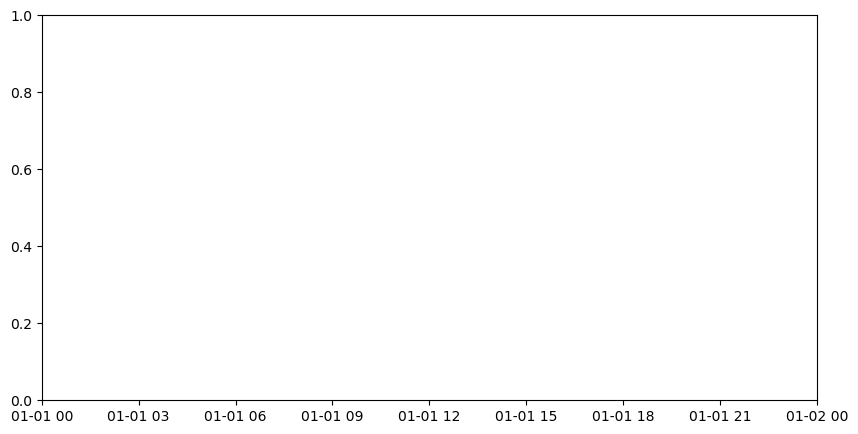

In [ ]:
# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data.values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
cell_data.values

array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
        ...,
        [ 1.79803672,  1.4361291 ,  1.57273752, ...,  

In [ ]:
cell_data

<xarray.DataArray 'tmmn' (time: 365, lat: 111, lon: 90)> Size: 29MB
array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
...
        [ 1.52569637,  1.34410989,  1.46348372, ...,  4.30947031,
          3.97875769,  2.95033412],
        [ 1.82136429,  1.78601274,  1.86385493, ...,  3.99203251,
          2.9065278 ,  1.87709451],
        [ 2.12006773,  2.27141311,  2.38213321, ...,  4.59372774,
          2.49923817,  1.4690442 ]],

       [[ 2.10918386,  2.38512955,  3.15067095, ...,  3.07061512,
          3.68448125,  2.98573553],
        [ 2.15017049,  2.89250049,  3.74666915, ...,  3.37899691,
          4.01672489,  2.79050034],
        [ 2.29769967,  2.87874913,  4.14227189, ...,  3.37683353,
          3.89464106,  2.39549151],
        ...,
        [ 0.54184817,  0.12629215,  0.2317426 , ...,  4.32772742,
          3.9430871 ,  2.79598264],
        [ 1.12112989,  0.82421634,  0.95630856, ...,  3.83705663,
          2.74400663,  1.58701032],
        [ 1.59225101,  1.6991172 ,  1.83895441, ...,  4.52179087,
          2.26621277,  1.1515435 ]]], shape=(365, 111, 90))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      float32 4B 40.12
    lon      float32 4B -110.1

In [ ]:
cell_data.lat

<xarray.DataArray 'lat' ()> Size: 4B
array(40.120266, dtype=float32)
Coordinates:
    lon      float32 4B -110.1
    lat      float32 4B 40.12

In [ ]:
cell_data.values

array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
        ...,
        [ 1.79803672,  1.4361291 ,  1.57273752, ...,  

In [ ]:
noise_masked

<xarray.Dataset> Size: 29MB
Dimensions:  (time: 365, lat: 111, lon: 90, south_north: 1, east_west: 1)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      (south_north, east_west) float32 4B 40.12
    lon      (south_north, east_west) float32 4B -110.1
Dimensions without coordinates: south_north, east_west
Data variables:
    tmmn     (time, lat, lon, south_north, east_west) float64 29MB 2.18 ... 1...

In [ ]:
cell_data

<xarray.DataArray 'tmmn' (time: 365, lat: 111, lon: 90)> Size: 29MB
array([[[ 2.17993756,  2.72638526,  3.94683623, ...,  4.14421043,
          4.53664674,  3.55149121],
        [ 2.38637004,  3.1017393 ,  4.32588933, ...,  4.10664449,
          4.7418228 ,  3.06887247],
        [ 2.29416325,  3.23679395,  4.66501906, ...,  3.99131386,
          4.64973565,  2.62085149],
        ...,
        [ 0.55686252,  0.05762185,  0.16840857, ...,  4.14138644,
          3.6245327 ,  2.75554431],
        [ 0.94639221,  0.60615485,  0.71763665, ...,  4.05604011,
          2.80065472,  1.75544605],
        [ 1.47043025,  1.59732973,  1.7498556 , ...,  4.72862423,
          2.49339652,  1.45529524]],

       [[ 3.17924696,  3.81472043,  4.74628055, ...,  4.07400491,
          4.83307768,  4.03433807],
        [ 3.21980865,  4.25371539,  5.23080756, ...,  4.10956153,
          4.81700343,  3.52711314],
        [ 3.38206273,  4.50285857,  5.66524111, ...,  3.97709095,
          4.513151  ,  2.95937495],
...
        [ 1.52569637,  1.34410989,  1.46348372, ...,  4.30947031,
          3.97875769,  2.95033412],
        [ 1.82136429,  1.78601274,  1.86385493, ...,  3.99203251,
          2.9065278 ,  1.87709451],
        [ 2.12006773,  2.27141311,  2.38213321, ...,  4.59372774,
          2.49923817,  1.4690442 ]],

       [[ 2.10918386,  2.38512955,  3.15067095, ...,  3.07061512,
          3.68448125,  2.98573553],
        [ 2.15017049,  2.89250049,  3.74666915, ...,  3.37899691,
          4.01672489,  2.79050034],
        [ 2.29769967,  2.87874913,  4.14227189, ...,  3.37683353,
          3.89464106,  2.39549151],
        ...,
        [ 0.54184817,  0.12629215,  0.2317426 , ...,  4.32772742,
          3.9430871 ,  2.79598264],
        [ 1.12112989,  0.82421634,  0.95630856, ...,  3.83705663,
          2.74400663,  1.58701032],
        [ 1.59225101,  1.6991172 ,  1.83895441, ...,  4.52179087,
          2.26621277,  1.1515435 ]]], shape=(365, 111, 90))
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lat      float32 4B 40.12
    lon      float32 4B -110.1

In [ ]:
cell_data.isel(lat = 0, lon = 0)

<xarray.DataArray 'tmmn' (time: 365)> Size: 3kB
array([2.17993756, 3.17924696, 2.53926447, 3.09003876, 3.56234549,
       3.53501959, 2.59484732, 3.15752251, 2.29809253, 1.67457713,
       2.81117774, 4.14186226, 3.57231981, 2.36324883, 3.99767345,
       2.25992621, 1.82806612, 2.0233526 , 2.15687367, 2.83115861,
       3.30717347, 2.9328379 , 2.76625851, 2.83026678, 2.15033876,
       2.26624649, 1.953657  , 1.9749339 , 1.92379096, 1.06613082,
       2.32199579, 2.43336613, 2.55714703, 2.36231862, 3.03198623,
       3.45259992, 4.2460498 , 3.83965304, 4.33984956, 3.58253516,
       3.18481414, 2.40087253, 2.44628176, 3.70920186, 2.09123675,
       2.24826085, 2.69276851, 2.03525883, 1.87828806, 1.65871693,
       2.74005913, 3.02055727, 2.29039947, 1.81102113, 2.55398795,
       2.94790739, 1.52022821, 2.09132956, 2.77730447, 3.63588053,
       4.24840579, 3.35293929, 2.92053261, 3.22990961, 2.34848671,
       3.25219524, 2.44589096, 1.96422711, 3.3055188 , 3.90502495,
       3.41650413, 2.98361064, 2.59808113, 2.12563678, 1.72997532,
       2.16202052, 1.61566399, 1.50920632, 2.35000903, 2.03353289,
       2.39977   , 1.79751451, 1.47072512, 1.74887645, 3.25156331,
       1.88108699, 1.8285275 , 2.46389131, 3.30396516, 2.79660674,
       3.73879558, 1.6873735 , 2.2250774 , 2.29431774, 1.89773563,
       2.29567851, 1.49841186, 2.56608754, 2.37441512, 2.90886347,
...
       6.18639997, 5.37466784, 5.59929909, 4.64132814, 4.20840365,
       4.73984783, 6.00425423, 4.89004666, 3.91624625, 3.65185095,
       3.21834785, 4.00768551, 3.77106574, 3.99076075, 4.9848594 ,
       4.89670134, 4.46613682, 4.27868147, 4.7832    , 4.47105848,
       2.76242779, 4.21146245, 3.17395117, 2.16903217, 2.43833624,
       3.27820286, 4.3960372 , 4.88765783, 4.8547876 , 4.72257788,
       4.32235759, 2.67654363, 2.99251284, 4.4148346 , 4.10064541,
       2.33340372, 2.12782612, 2.65398287, 2.50178448, 3.11634746,
       3.48970048, 4.10064222, 3.16357066, 3.56693024, 3.7665104 ,
       2.87173614, 2.51032848, 2.25425786, 2.66959538, 2.32122286,
       1.98251215, 1.77010745, 1.76353865, 3.26586823, 3.56202173,
       2.71173034, 1.64218975, 1.89075378, 2.57634337, 2.02669273,
       1.83171291, 2.62943909, 2.71901949, 1.89216335, 1.25809359,
       1.07082284, 1.92634948, 2.18054441, 2.65756956, 0.90268753,
       0.55568819, 3.23862698, 2.74051887, 2.50485736, 2.49501864,
       1.62441968, 1.37884017, 2.24118416, 3.13414474, 2.98162186,
       2.37905061, 1.89283709, 2.42986422, 2.55271247, 1.77938871,
       1.90522885, 1.28855875, 2.89113612, 3.83791024, 3.47280224,
       2.64410202, 3.01652386, 3.21652727, 2.75672021, 3.80793431,
       2.62111473, 1.18096241, 1.90845568, 3.14880191, 2.10918386])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lon      float32 4B -110.1
    lat      float32 4B 40.12

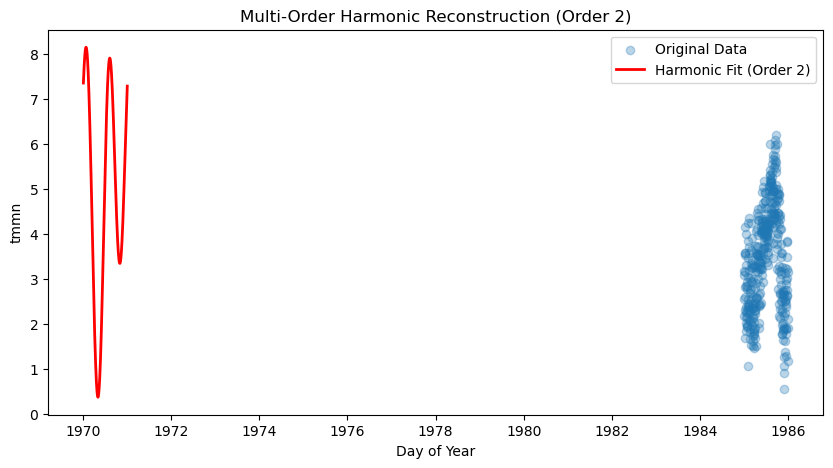

In [ ]:
# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize=(10, 5))
plt.scatter(cell_data['time'], 
            cell_data.isel(lat = 0, lon = 0).values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
cell_data['time']

<xarray.DataArray 'time' (time: 365)> Size: 3kB
array(['1985-01-01T00:00:00.000000000', '1985-01-02T00:00:00.000000000',
       '1985-01-03T00:00:00.000000000', ..., '1985-12-29T00:00:00.000000000',
       '1985-12-30T00:00:00.000000000', '1985-12-31T00:00:00.000000000'],
      shape=(365,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1985-01-01 1985-01-02 ... 1985-12-31
    lon      float32 4B -110.1
    lat      float32 4B 40.12

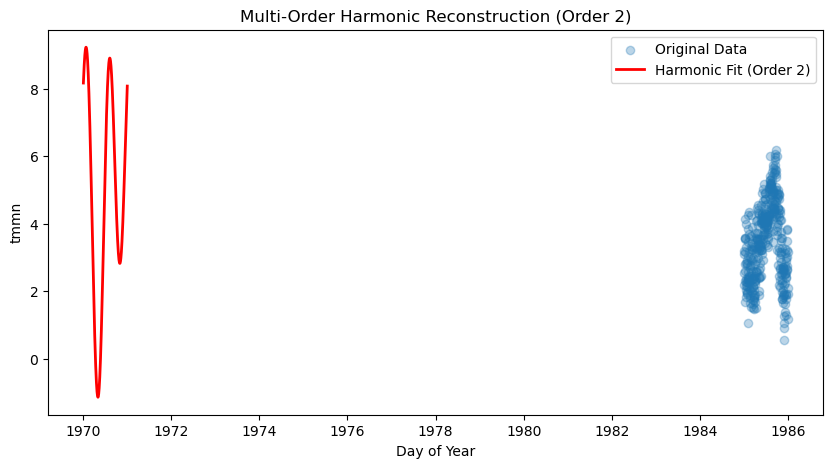

In [ ]:
# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff=(2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff=(2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize = (10, 5))
plt.scatter(cell_data['time'].values, 
            cell_data.isel(lat = 0, lon = 0).values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(d_plot, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
d_plot

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 15

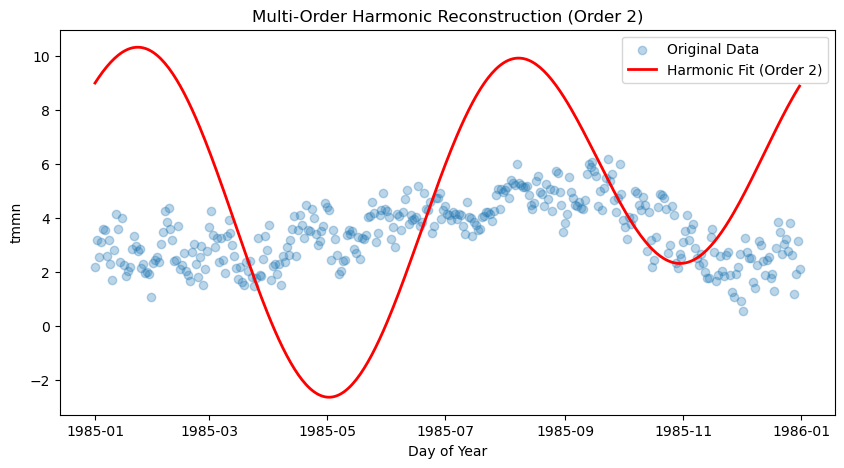

In [ ]:
# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff = (2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff = (2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize = (10, 5))
plt.scatter(cell_data['time'].values, 
            cell_data.isel(lat = 0, lon = 0).values, 
            alpha = 0.3, label = 'Original Data')
plt.plot(cell_data['time'].values, y_pred, color='red', linewidth=2, label=f'Harmonic Fit (Order {order})')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
cell_coeffs

<xarray.DataArray 'tmmn' (south_north: 1, east_west: 1, coeff: 5)> Size: 40B
array([[[ 4.89371303,  0.28094711, -0.41015611,  0.514871  ,
          0.87252505]]])
Coordinates:
    lon      (south_north, east_west) float32 4B -110.1
    lat      (south_north, east_west) float32 4B 40.12
Dimensions without coordinates: south_north, east_west, coeff

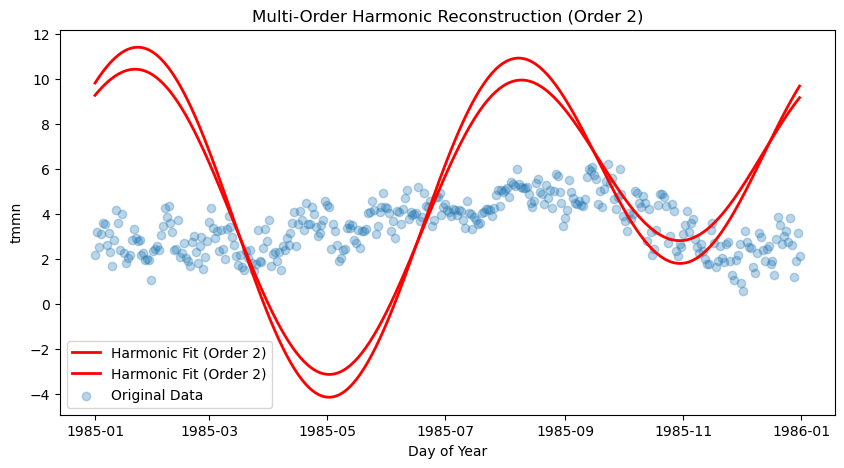

In [ ]:
# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize = (10, 5))

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff = (2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff = (2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

    # plot harmonic fit
    plt.plot(cell_data['time'].values, y_pred, color = 'red', linewidth = 2, label = f'Harmonic Fit (Order {order})')

plt.scatter(cell_data['time'].values, 
            cell_data.isel(lat = 0, lon = 0).values, 
            alpha = 0.3, label = 'Original Data')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

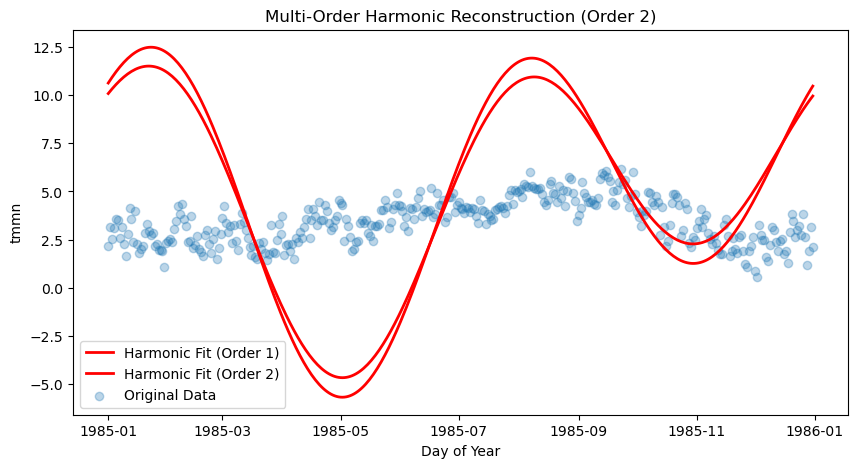

In [ ]:
# 4. Plot the original data vs the multi-order harmonic fit
plt.figure(figsize = (10, 5))

# Loop through each order n (starting at 1)
for n in range(1, order + 1):
    # Dynamically select the exact cosine and sine coefficient indices for order n
    # (Cosine is typically at odd positions, Sine at even positions)
    a_n = float(cell_coeffs.sel(coeff = (2 * n - 1)).values[0][0])
    b_n = float(cell_coeffs.sel(coeff = (2 * n)).values[0][0])
    
    # Add the harmonic wave component for this order
    y_pred += a_n * np.cos(n * omega * d_plot) + b_n * np.sin(n * omega * d_plot)

    # plot harmonic fit
    plt.plot(cell_data['time'].values, y_pred, color = 'red', linewidth = 2, label = f'Harmonic Fit (Order {n})')

plt.scatter(cell_data['time'].values, 
            cell_data.isel(lat = 0, lon = 0).values, 
            alpha = 0.3, label = 'Original Data')
plt.xlabel('Day of Year')
plt.ylabel(var)
plt.legend()
plt.title(f'Multi-Order Harmonic Reconstruction (Order {order})')
plt.show()

In [ ]:
test = harmonic_formula(order = 3)

In [ ]:
test

'y_var ~ np.cos(1 * (2 * np.pi * d)/365) + np.sin(1 * (2 * np.pi * d)/365) + np.cos(2 * (2 * np.pi * d)/365) + np.sin(2 * (2 * np.pi * d)/365) + np.cos(3 * (2 * np.pi * d)/365) + np.sin(3 * (2 * np.pi * d)/365)'